 Membaca JSONL & Membuat Kolom Multilabel (One-Hot Encoding)...
   -> Selesai mengekstrak data teks dan 13 komponen label biner.

Melakukan Data Splitting Proyek A (CSV)...
   Proyek A Sukses! Train: 2218, Val: 475, Test: 476

Melakukan Data Splitting Proyek B (JSONL)...
   Proyek B Sukses! Train: 2218, Val: 475, Test: 476

Semua 6 file split data wajib di folder dataset!

Menggambar Grafik EDA Proyek A...


C:\Users\PC\AppData\Local\Temp\ipykernel_28940\3784723486.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.values, y=label_counts.index, ax=axes[1, 0], palette='viridis')


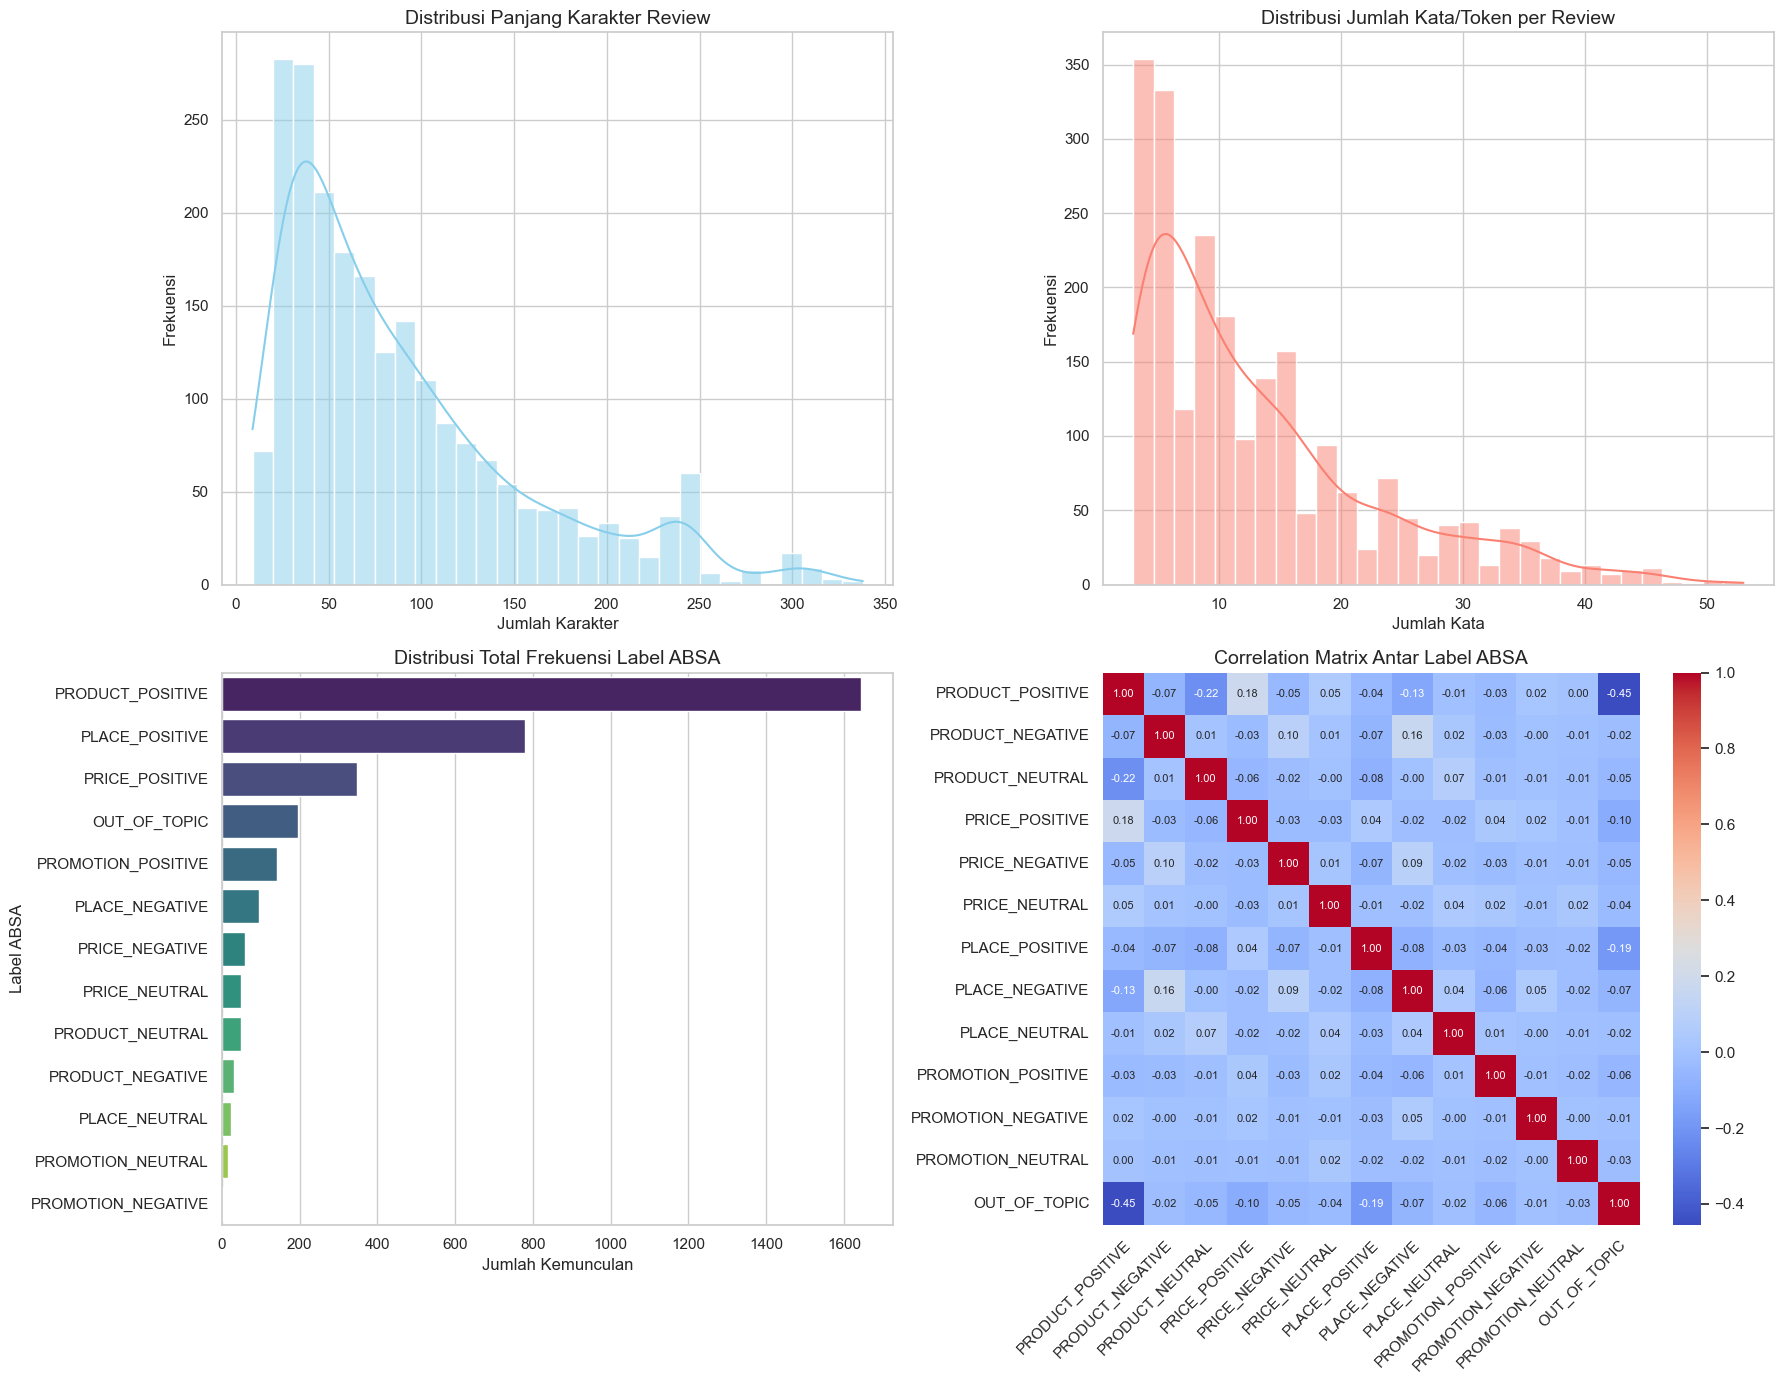

Pemrosesan data dan visualisasi selesai


In [5]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


dataset_dir = '../dataset'

# 13 Skema Label
list_label = [
    'PRODUCT_POSITIVE', 'PRODUCT_NEGATIVE', 'PRODUCT_NEUTRAL', 
    'PRICE_POSITIVE', 'PRICE_NEGATIVE', 'PRICE_NEUTRAL',
    'PLACE_POSITIVE', 'PLACE_NEGATIVE', 'PLACE_NEUTRAL',
    'PROMOTION_POSITIVE', 'PROMOTION_NEGATIVE', 'PROMOTION_NEUTRAL', 
    'OUT_OF_TOPIC'
]

print(" Membaca JSONL & Membuat Kolom Multilabel (One-Hot Encoding)...")
jsonl_path = os.path.join(dataset_dir, 'Kelp3_dataset_anotasi.jsonl')

if not os.path.exists(jsonl_path):
    print(f"Error: File {jsonl_path} tidak ditemukan! Pastikan posisinya benar.")
else:
    with open(jsonl_path, 'r', encoding='utf-8') as f:
        data_ner_master = [json.loads(line) for line in f]
    
    # Ekstrak data untuk keperluan tabel biner Multilabel
    records_ml = []
    for data in data_ner_master:
        text = data.get('text', '')
        labels = data.get('accept', [])
        
        row = {'cleaned_text': text}
        for lbl in list_label:
            row[lbl] = 1 if lbl in labels else 0
        records_ml.append(row)
        
    df_multilabel_master = pd.DataFrame(records_ml)
    print("   -> Selesai mengekstrak data teks dan 13 komponen label biner.")

    # Memotong Data Proyek A (Multilabel Text Classification)
    print("\nMelakukan Data Splitting Proyek A (CSV)...")
    train_ml, temp_ml = train_test_split(df_multilabel_master, test_size=0.30, random_state=42)
    val_ml, test_ml = train_test_split(temp_ml, test_size=0.50, random_state=42)
    
    # Simpan berkas CSV baru yang sudah lengkap dengan 13 kolom label
    train_ml.to_csv(os.path.join(dataset_dir, 'Kelp3_multilabel_train.csv'), index=False)
    val_ml.to_csv(os.path.join(dataset_dir, 'Kelp3_multilabel_val.csv'), index=False)
    test_ml.to_csv(os.path.join(dataset_dir, 'Kelp3_multilabel_test.csv'), index=False)
    print(f"   Proyek A Sukses! Train: {len(train_ml)}, Val: {len(val_ml)}, Test: {len(test_ml)}")

    # Memotong Data Proyek B (Named Entity Recognition)
    print("\nMelakukan Data Splitting Proyek B (JSONL)...")
    # random_state=42 yang sama persis agar baris urutannya sinkron
    train_ner, temp_ner = train_test_split(data_ner_master, test_size=0.30, random_state=42)
    val_ner, test_ner = train_test_split(temp_ner, test_size=0.50, random_state=42)
    
    # Helper function untuk menyimpan file format JSONL
    def save_jsonl(data, filename):
        output_path = os.path.join(dataset_dir, filename)
        with open(output_path, 'w', encoding='utf-8') as out_f:
            for item in data:
                out_f.write(json.dumps(item, ensure_ascii=False) + '\n')
                
    # Simpan berkas JSONL hasil pemotongan
    save_jsonl(train_ner, 'Kelp3_ner_train.jsonl')
    save_jsonl(val_ner, 'Kelp3_ner_val.jsonl')
    save_jsonl(test_ner, 'Kelp3_ner_test.jsonl')
    print(f"   Proyek B Sukses! Train: {len(train_ner)}, Val: {len(val_ner)}, Test: {len(test_ner)}")
    print("\nSemua 6 file split data wajib di folder dataset!")

    # Menggambar Grafik EDA (Kriteria Penilaian Nilai 95)
    print("\nMenggambar Grafik EDA Proyek A...")
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    # GRAPH 1: Distribusi Panjang Karakter Review
    train_ml['char_length'] = train_ml['cleaned_text'].astype(str).apply(len)
    sns.histplot(train_ml['char_length'], bins=30, kde=True, ax=axes[0, 0], color='skyblue')
    axes[0, 0].set_title('Distribusi Panjang Karakter Review', fontsize=14)
    axes[0, 0].set_xlabel('Jumlah Karakter')
    axes[0, 0].set_ylabel('Frekuensi')

    # GRAPH 2: Distribusi Jumlah Kata/Token per Review
    train_ml['word_count'] = train_ml['cleaned_text'].astype(str).apply(lambda x: len(x.split()))
    sns.histplot(train_ml['word_count'], bins=30, kde=True, ax=axes[0, 1], color='salmon')
    axes[0, 1].set_title('Distribusi Jumlah Kata/Token per Review', fontsize=14)
    axes[0, 1].set_xlabel('Jumlah Kata')
    axes[0, 1].set_ylabel('Frekuensi')

    # GRAPH 3: Distribusi Kemunculan Setiap Label ABSA (Mendeteksi Imbalance)
    label_counts = train_ml[list_label].sum().sort_values(ascending=False)
    sns.barplot(x=label_counts.values, y=label_counts.index, ax=axes[1, 0], palette='viridis')
    axes[1, 0].set_title('Distribusi Total Frekuensi Label ABSA', fontsize=14)
    axes[1, 0].set_xlabel('Jumlah Kemunculan')
    axes[1, 0].set_ylabel('Label ABSA')

    # GRAPH 4: Correlation Matrix antar Label (Melihat Hubungan Aspek)
    corr_matrix = train_ml[list_label].corr()
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1, 1], 
                cbar=True, annot_kws={"size": 8}, xticklabels=list_label, yticklabels=list_label)
    axes[1, 1].set_title('Correlation Matrix Antar Label ABSA', fontsize=14)
    plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    plt.tight_layout()
    plt.show()
    print("Pemrosesan data dan visualisasi selesai")

In [1]:
import re
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

print("Membaca data train, validation, dan test untuk Proyek A...")
# Load data yang sudah di-split di Step 2 sebelumnya
train_df = pd.read_csv('../dataset/Kelp3_multilabel_train.csv')
val_df = pd.read_csv('../dataset/Kelp3_multilabel_val.csv')
test_df = pd.read_csv('../dataset/Kelp3_multilabel_test.csv')

# DATA PREPROCESSING (CLEANING FUNCTION)
def clean_indonesian_text(text):
    if pd.isna(text):
        return ""
    # 1. Case folding (mengubah semua huruf menjadi kecil)
    text = str(text).lower()
    # 2. Menghapus tautan/URL
    text = re.sub(r'https?://\s+|www\.\s+', '', text)
    # 3. Menghapus karakter aneh, emoji, dan tanda baca (hanya menyisakan huruf, angka, dan spasi)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    # 4. Menghapus spasi ganda yang berlebihan
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("\nMenjalankan proses Preprocessing / Cleaning Teks...")
# nerapin fungsi cleaning ke semua pembagian data
train_df['clean_text'] = train_df['cleaned_text'].apply(clean_indonesian_text)
val_df['clean_text'] = val_df['cleaned_text'].apply(clean_indonesian_text)
test_df['clean_text'] = test_df['cleaned_text'].apply(clean_indonesian_text)

print("Contoh hasil sebelum vs sesudah preprocessing:")
print(f"Sebelum: {train_df['cleaned_text'].iloc[1][:90]}...")
print(f"Sesudah: {train_df['clean_text'].iloc[1][:90]}...")


# FEATURE ENGINEERING (REPRESENTASI TEKS 1 - TF-IDF N-GRAM)
print("\nMembuat Representasi Teks Pertama: TF-IDF (Unigram + Bigram)...")

# Inisialisasi TF-IDF Vectorizer
# ngram_range=(1, 2) artinya kita mengambil kata tunggal (unigram) dan kombinasi 2 kata berurutan (bigram)
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)

# Fit ke data train, lalu transform ke train, val, dan test
X_train_tfidf = tfidf_vectorizer.fit_transform(train_df['clean_text'])
X_val_tfidf = tfidf_vectorizer.transform(val_df['clean_text'])
X_test_tfidf = tfidf_vectorizer.transform(test_df['clean_text'])

print(f"Matriks TF-IDF Train berhasil dibuat dengan ukuran: {X_train_tfidf.shape}")
print("Sukses! Langkah Preprocessing dan Representasi Teks Pertama telah selesai.")

Membaca data train, validation, dan test untuk Proyek A...

Menjalankan proses Preprocessing / Cleaning Teks...
Contoh hasil sebelum vs sesudah preprocessing:
Sebelum: Pas buat emak emak yg suka shopping......
Sesudah: pas buat emak emak yg suka shopping...

Membuat Representasi Teks Pertama: TF-IDF (Unigram + Bigram)...
Matriks TF-IDF Train berhasil dibuat dengan ukuran: (2218, 5000)
Sukses! Langkah Preprocessing dan Representasi Teks Pertama telah selesai.


In [2]:
import pandas as pd
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, hamming_loss, accuracy_score

# 1. menyiapkan data target label (Y) untuk Train dan Validation
list_label = [
    'PRODUCT_POSITIVE', 'PRODUCT_NEGATIVE', 'PRODUCT_NEUTRAL', 
    'PRICE_POSITIVE', 'PRICE_NEGATIVE', 'PRICE_NEUTRAL',
    'PLACE_POSITIVE', 'PLACE_NEGATIVE', 'PLACE_NEUTRAL',
    'PROMOTION_POSITIVE', 'PROMOTION_NEGATIVE', 'PROMOTION_NEUTRAL', 
    'OUT_OF_TOPIC'
]

y_train = train_df[list_label]
y_val = val_df[list_label]

# 2. mendefinisikan 2 Algoritma ML dan 2 Teknik Transformasi Masalah
# pakai LinearSVC (SVM) dan Logistic Regression karena sangat cepat & kuat untuk TF-IDF
models_pool = {
    'SVM (LinearSVC)': LinearSVC(random_state=42, class_weight='balanced'),
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
}

print("Memulai eksperimen pelatihan model multilabel...")
eksperimen_results = []

# Loop untuk mengombinasikan Algoritma dan Problem Transformation
for algo_name, algo_obj in models_pool.items():
    
    # TEKNIK 1 BINARY RELEVANCE (MultiOutputClassifier)
    br_model = MultiOutputClassifier(algo_obj)
    br_model.fit(X_train_tfidf, y_train)
    br_pred = br_model.predict(X_val_tfidf)
    
    eksperimen_results.append({
        'Pendekatan': 'Binary Relevance',
        'Algoritma': algo_name,
        'Subset Accuracy (Strict)': accuracy_score(y_val, br_pred),
        'Hamming Loss': hamming_loss(y_val, br_pred),
        'Macro F1-Score': f1_score(y_val, br_pred, average='macro'),
        'Micro F1-Score': f1_score(y_val, br_pred, average='micro')
    })
    
    # TEKNIK 2 CLASSIFIER CHAINS
    cc_model = ClassifierChain(algo_obj, order='random', random_state=42)
    cc_model.fit(X_train_tfidf, y_train)
    cc_pred = cc_model.predict(X_val_tfidf)
    
    eksperimen_results.append({
        'Pendekatan': 'Classifier Chains',
        'Algoritma': algo_name,
        'Subset Accuracy (Strict)': accuracy_score(y_val, cc_pred),
        'Hamming Loss': hamming_loss(y_val, cc_pred),
        'Macro F1-Score': f1_score(y_val, cc_pred, average='macro'),
        'Micro F1-Score': f1_score(y_val, cc_pred, average='micro')
    })

# 3. Rekap hasil ke dalam DataFrame
df_metrik_uas = pd.DataFrame(eksperimen_results)

print("\nHASIL PERBANDINGAN EKSPERIMEN MODEL MULTILABEL (DATA VALIDASI):")
display(df_metrik_uas.sort_values(by='Macro F1-Score', ascending=False))

Memulai eksperimen pelatihan model multilabel...

HASIL PERBANDINGAN EKSPERIMEN MODEL MULTILABEL (DATA VALIDASI):


,Pendekatan,Algoritma,Subset Accuracy (Strict),Hamming Loss,Macro F1-Score,Micro F1-Score
2,Binary Relevance,Logistic Regression,0.444211,0.065911,0.426257,0.737589
1,Classifier Chains,SVM (LinearSVC),0.469474,0.067692,0.413208,0.723179
0,Binary Relevance,SVM (LinearSVC),0.461053,0.068664,0.410731,0.721785
3,Classifier Chains,Logistic Regression,0.450526,0.076113,0.387673,0.693211


In [3]:
import numpy as np
from sklearn.metrics import classification_report, hamming_loss, accuracy_score

# 1. Ambil target label asli untuk data test
y_test = test_df[list_label]

print("Melatih ulang model terbaik pada data Train untuk dievaluasi ke Test Set...")
# menggunakan kombinasi terbaik Binary Relevance + Logistic Regression
best_model = MultiOutputClassifier(LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000))
best_model.fit(X_train_tfidf, y_train)

# 2. Prediksi ke Data Test
y_pred_test = best_model.predict(X_test_tfidf)

# 3. menampilkan Metrik Evaluasi Global di Test Set
print("\n========================================================")
print("HASIL EVALUASI MODEL TERBAIK PADA TEST SET")
print("========================================================")
print(f"Subset Accuracy (Strict) : {accuracy_score(y_test, y_pred_test):.4f}")
print(f"Hamming Loss             : {hamming_loss(y_test, y_pred_test):.4f}")
print("========================================================\n")

# 4. menampilkan Classification Report per Label
print("CLASSIFICATION REPORT PER LABEL:")
print(classification_report(y_test, y_pred_test, target_names=list_label, zero_division=0))

# 5. KODE ANALISIS KESALAHAN (ERROR ANALYSIS)
print("\nMEMULAI ANALISIS KESALAHAN MODEL (CONTOH KASUS SALAH PREDIKSI):")
print("====================================================================")

# mencari baris mana saja yang hasil prediksinya tidak sama persis dengan label asli
salah_indeks = np.where(np.any(y_test.values != y_pred_test, axis=1))[0]

count = 0
for idx in salah_indeks:
    if count >= 3: # menampilkan 3 contoh
        break
    
    # Ambil teks asli sebelum di-clean agar mudah dibaca di laporan
    teks_asli = test_df['cleaned_text'].iloc[idx]
    
    # Ambil label asli yang bernilai 1
    label_asli_aktif = [list_label[i] for i, val in enumerate(y_test.values[idx]) if val == 1]
    # Ambil label hasil prediksi yang bernilai 1
    label_pred_aktif = [list_label[i] for i, val in enumerate(y_pred_test[idx]) if val == 1]
    
    print(f"\nContoh Salah {count+1}:")
    print(f"   Teks Review : '{teks_asli[:150]}...'")
    print(f"   Label Asli  : {label_asli_aktif}")
    print(f"   AI Menebak  : {label_pred_aktif}")
    print("-" * 68)
    count += 1

Melatih ulang model terbaik pada data Train untuk dievaluasi ke Test Set...

HASIL EVALUASI MODEL TERBAIK PADA TEST SET
Subset Accuracy (Strict) : 0.4769
Hamming Loss             : 0.0682

CLASSIFICATION REPORT PER LABEL:
                    precision    recall  f1-score   support

  PRODUCT_POSITIVE       0.91      0.87      0.89       367
  PRODUCT_NEGATIVE       0.50      0.45      0.48        11
   PRODUCT_NEUTRAL       0.14      0.29      0.19        14
    PRICE_POSITIVE       0.84      0.94      0.88        77
    PRICE_NEGATIVE       0.56      0.82      0.67        11
     PRICE_NEUTRAL       0.31      0.42      0.36        12
    PLACE_POSITIVE       0.68      0.70      0.69       167
    PLACE_NEGATIVE       0.78      0.82      0.80        22
     PLACE_NEUTRAL       0.10      0.20      0.13         5
PROMOTION_POSITIVE       0.16      0.40      0.23        25
PROMOTION_NEGATIVE       0.00      0.00      0.00         4
 PROMOTION_NEUTRAL       0.00      0.00      0.00        

In [4]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Simpan model terbaik dan vectorizer TF-IDF-nya
joblib.dump(best_model, '../models/Kelp3_best_multilabel_model.pkl')
joblib.dump(tfidf_vectorizer, '../models/Kelp3_tfidf_vectorizer.pkl')

print("Model klasifikasi multilabel dan TF-IDF Vectorizer berhasil disimpan di folder models/ !")

Model klasifikasi multilabel dan TF-IDF Vectorizer berhasil disimpan di folder models/ !
